In [1]:
import gpytoolbox as gpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import matplotlib.patches as mp
import trimesh

import dvx_ext
dvx_ext.build_type()

'Release'

In [12]:
mesh = trimesh.load_mesh("hand.obj")
# v, f = np.array(mesh.vertices, dtype=np.float32), np.array(mesh.faces, dtype=np.int32)
# v *= 1.6
v, f = gpy.icosphere(1)
v *= 0.9
print(v.min(), v.max())

occupancy = np.zeros((16, 16, 16), dtype=np.float32)
filter_radius = (2 / occupancy.shape[0]) / 2
dvx_ext.voxelize_mc_f32(v, f, occupancy, num_samples_per_voxel=4, filter_radius=filter_radius)
print(occupancy.min(), occupancy.max())

-0.9 0.9
This can result in voxels without valid samples. Consider increasing the sample count or the filter radius.
This can result in voxels without valid samples. Consider increasing the sample count or the filter radius.
This can result in voxels without valid samples. Consider increasing the sample count or the filter radius.
-8.7007834e-08 1.0000004


In [3]:
import polyscope as ps
import numpy as np

ps.init()

# define the resolution and bounds of the grid
dims = occupancy.shape
bound_low = (0., 0., 0.)
bound_high = (1., 1., 1.)

# register the grid
ps_grid = ps.register_volume_grid("sample grid", dims, bound_low, bound_high)

# add a scalar function on the grid
ps_grid.add_scalar_quantity("node scalar1", occupancy, 
                            defined_on='nodes', vminmax=(0., 1.), enabled=True)

ps.show()

In [15]:
vertex_id = 0

d_vertices = np.zeros_like(v, dtype=np.float32)
d_vertices[vertex_id, 0] = 1

# Finite differences
ε = 1e-1
occupancy_fwd = np.zeros((16, 16, 16), dtype=np.float32)
dvx_ext.voxelize_mc_f32(v + ε * d_vertices, f, occupancy_fwd, num_samples_per_voxel=4*1024, filter_radius=filter_radius)
occupancy_bwd = np.zeros((16, 16, 16), dtype=np.float32)
dvx_ext.voxelize_mc_f32(v - ε * d_vertices, f, occupancy_bwd, num_samples_per_voxel=4*1024, filter_radius=filter_radius)
d_occupancy_fd = (occupancy_fwd - occupancy_bwd) / (2 * ε)

r = np.quantile(np.abs(d_occupancy_fd), q=0.999)
print(r)

0.8181712


r=0.8181712031364441
0.9933456


C:\Users\mworchel\AppData\Local\Temp\ipykernel_98008\2915436712.py:7: RuntimeWarning: divide by zero encountered in divide
  ratio = (d_occupancy_fd / d_occupancy)
C:\Users\mworchel\AppData\Local\Temp\ipykernel_98008\2915436712.py:7: RuntimeWarning: invalid value encountered in divide
  ratio = (d_occupancy_fd / d_occupancy)


Text(0.5, 1.0, 'Finite Differences')

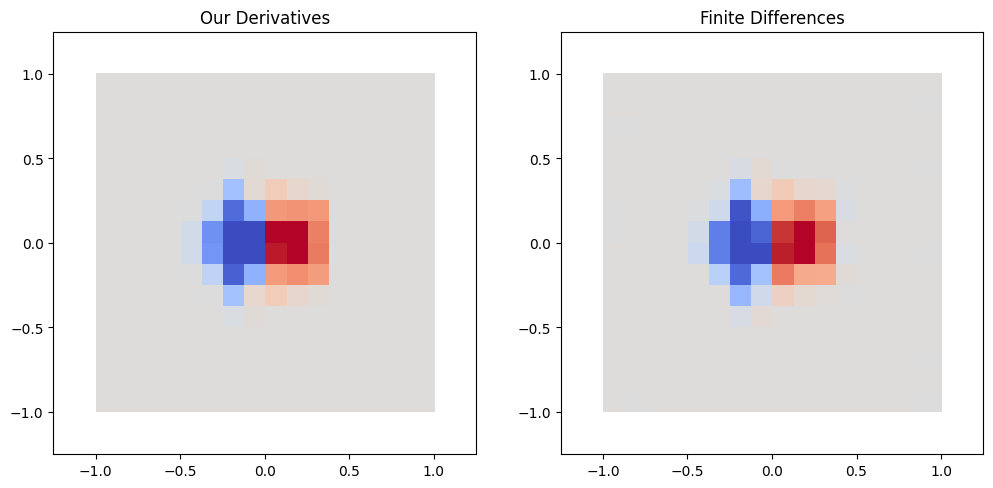

In [22]:
occupancy   = np.zeros((16, 16, 16), dtype=np.float32)
d_occupancy = np.zeros((16, 16, 16), dtype=np.float32)
dvx_ext.voxelize_forward_mc_f32(v, f, occupancy, d_vertices, d_occupancy, num_samples_per_simplex=4*4096, filter_radius=filter_radius)

print(f"r={r}")

ratio = (d_occupancy_fd / d_occupancy)
print(np.median(ratio[np.isfinite(ratio)]))

slice_index = 14

domain_scale = 1.25
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    axs[i].set_ylim(-1*domain_scale, 1*domain_scale)
    axs[i].set_xlim(-1*domain_scale, 1*domain_scale)
    #axs[i].scatter(*vertices[vertex_id:vertex_id+1].T)
    #axs[i].quiver(*vertices[vertex_id:vertex_id+1].T, *d_vertices[vertex_id:vertex_id+1].T)
axs[0].imshow(d_occupancy[slice_index], extent=(-1, 1, 1, -1), vmin=-r, vmax=r, cmap='coolwarm')
axs[0].set_title("Our Derivatives")
axs[1].imshow(d_occupancy_fd[slice_index], extent=(-1, 1, 1, -1), vmin=-r, vmax=r, cmap='coolwarm')
axs[1].set_title("Finite Differences")